To run this code, please create a new conda environment using the yaml file provided in this directory.

To recreate this environment, users should run the following from within this directory:
  
  conda env create -f environment.yml
  
  conda activate cvpca-analysis

In [1]:
from sklearn.decomposition import PCA
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
import matplotlib
import scipy
import mat73
import os
from pathlib import Path

In [ ]:
# HELPER FUNCTIONS
def loadWholeBodyData(dataLoc):
    # loads participant data and returns in dictionary 'data'
    data = {}
    try:
        d = loadmat(dataLoc)
        data['tx'] = d['DataMat'][0][0][0] # tx
        data['tx_blkMeanSub'] = d['DataMat'][0][0][1] # tx_blkMeanSub - Tx192
        data['blkNum'] = d['DataMat'][0][0][2] # blknum
        data['trialCue'] = d['DataMat'][0][0][3] -1 # trialCue
        data['goCue'] = d['DataMat'][0][0][4] -1 # goCue
        
        cues = d['DataMat'][0][0][7] # cueList
        data['cueList'] = np.array([cue[0][0] for cue in cues])
        
        data['binWidth'] = d['DataMat'][0][0][8] # binWidth
        data['chanSets'] = d['DataMat'][0][0][9][0] - 1# chanSets
        
        data['chanSetNames'] = d['DataMat'][0][0][10][0] # chanSetNames
    except:
        d = mat73.loadmat(dataLoc)
        data['tx'] = d['DataMat']['tx']
        data['tx_blkMeanSub'] = d['DataMat']['tx_blkMeanSub'] # tx_blkMeanSub - Tx192
        data['blkNum'] = d['DataMat']['blockNum'] # blknum
        data['trialCue'] = d['DataMat']['trialCue'] -1 # trialCue
        data['goCue'] = d['DataMat']['goCue'] -1 # goCue
        data['goCue'] = data['goCue'].astype(int)
        
        cues = d['DataMat']['cueList'] # cueList
        data['cueList'] = np.array([cue for cue in cues])
        
        data['binWidth'] = d['DataMat']['binWidth'] # binWidth
        raw_chans = d['DataMat']['chanSets']
        # Coerce to a flat Python list, dropping any None cells
        chans_list = []
        for c in (raw_chans if isinstance(raw_chans, list) else list(np.asarray(raw_chans).ravel())):
            if c is None:
                continue
            arr = np.asarray(c).ravel().astype(np.int64) - 1   # 1- → 0-indexed
            chans_list.append(arr)
        data['chanSets'] = chans_list
        data['chanSetNames'] = np.array([np.array([i]) for i in d['DataMat']['chanSetNames']])

    return data


#########################################################################################################################################
def computeFeatureMatrices(data, timeWindow, feature='tx_blkMeanSub', chanSetName='', zscore=True):
    # constructs Features Tensor which is NxCxTxR => N is # neurons, C is # of unique conditions, T is # of Timesteps in movement window, R is # of repetitions
    # takes as input the data dictionary created by loadWholeBodyData
    # takes as input the features to construct tensor with
    # takes as input the channel set name
    # takes as input the time window which is a list of beginning and ending of window in 20ms bins => ie [15, 75] indicate 300ms to 1.5s with 20ms bins
    
    T_window = np.array(range(timeWindow[0],timeWindow[1]+1))
    indChanSet = np.where(data['chanSetNames'] == chanSetName)[0][0]
    chanInds = data['chanSets'][indChanSet].flatten().astype(int)
    
    feats = data[feature][:,chanInds] # TxN
    
    if zscore:
        feats = (feats-np.nanmean(feats,0))/np.nanstd(feats,0)
    
    feats = np.nan_to_num(feats, nan=0.0)
        
    trialCues = data['trialCue']
    goCues = data['goCue']

    uniqueTrlCues, counts = np.unique(trialCues, return_counts=True)
    numReps = min(counts)

    N = feats.shape[1]
    C = uniqueTrlCues.size
    T = timeWindow[1]-timeWindow[0]+1
    R = numReps
    
    FeatureVals = np.ndarray((N,C,T,R))

    # iterate through each trialCue and append 
    for ic,c in enumerate(uniqueTrlCues):
        currCondInds = np.where(trialCues == c)[0]
        currGoCues = goCues[currCondInds]
        for gi,g in enumerate(currGoCues):
            if gi < R: # make sure this doesn't exceed the maximum number of repetitions
                window = g+T_window
                currWindow = feats[window,:] # TxN
                FeatureVals[:,ic,:,gi] = currWindow.T

    return FeatureVals, uniqueTrlCues

#########################################################################################################################################
def cvPCA_Iter(X, numIterations=100):
    N, C, T, R = X.shape
    # Perform cross-validated PCA with split-half validation
    ss_norm_array = []
    for i in range(numIterations):
        N, C, T, R = X.shape
        X_windowAvg = np.nanmean(X, axis=2)
        
        N, C, R = X_windowAvg.shape # NxCxReps

        # compute average across all feature vectors and mean-subtract
        mu = np.nanmean(X_windowAvg.reshape(N, R*C), axis=1)
        X_windowAvg_meanCtr = X_windowAvg - mu[:, np.newaxis, np.newaxis]
    
        # randomly split the trial reps
        half = R//2
        # generate rand inds to pull repetitions
        R_inds = np.random.permutation(R)
        i_1 = R_inds[:half]
        i_2 = R_inds[half:half*2]
        
        # split data into two halves
        X1 = X_windowAvg_meanCtr[:,:,i_1]
        X2 = X_windowAvg_meanCtr[:,:,i_2]
        
        # trial-avg within condition
        X1_trlAvg = np.nanmean(X1, axis=2) # NxC
        X2_trlAvg = np.nanmean(X2, axis=2) # NxC
        
        # store into X variable to pass into cvPCA function
        X_compiled = np.ndarray((2,C,N))
        X_compiled[0,:,:] = X1_trlAvg.T
        X_compiled[1,:,:] = X2_trlAvg.T

        ss = cvPCA(X_compiled)
        ss_norm_array.append(ss)
        
    ss_norm_array = np.array(ss_norm_array)
    mean_cumss = np.mean(ss_norm_array, axis=0)
    stds_cumss = np.std(ss_norm_array, axis=0)

    return ss_norm_array, mean_cumss, stds_cumss

#########################################################################################################################################
def cvPCA(X):
    ''' X is 2 x stimuli x neurons - performs cross-validated PCA '''
    pca = PCA(n_components=min(1024, X.shape[1])).fit(X[0].T)
    u = pca.components_.T
    sv = pca.singular_values_
    
    xproj = X[0].T @ (u / sv)
    cproj0 = X[0] @ xproj
    cproj1 = X[1] @ xproj
    ss = (cproj0 * cproj1).sum(axis=0)
    return ss

#########################################################################################################################################
def getMoveSets(mvSetName):
    # Helper function that returns an array of the condition numbers for the desired movement set
    if mvSetName == 'RightArm':
        mvNums = np.array([30, 31, 32, 33, 38, 39, 40, 41])-1
    elif mvSetName == 'LeftArm':
        mvNums = np.array([11, 12, 13, 14, 19, 20, 21, 22])-1
    elif mvSetName == 'RightLeg':
        mvNums = np.array([26, 27, 28, 29, 34, 35, 36, 37])-1
    elif mvSetName == 'LeftLeg':
        mvNums = np.array([7, 8, 9, 10, 15, 16, 17, 18])-1
    elif mvSetName == 'Speech':
        mvNums = np.array([42, 43, 44, 45])-1
    elif mvSetName == 'Face':
        mvNums = np.array([2, 23, 24, 25, 46])-1
    elif mvSetName == 'Head':
        mvNums = np.array([3, 4, 5, 6])-1
    elif mvSetName == 'DoNothing':
        mvNums = np.array([1])-1
    elif mvSetName == 'dorsal_nonCanonical':
        mvNums = np.array([42, 43, 44, 45, 2, 23, 24, 25, 46])-1 # speech/face
    elif mvSetName == 'ventral_nonCanonical': # r/l arms legs
        mvNums = np.array([30, 31, 32, 33, 38, 39, 40, 41, 11, 12, 13, 14, 19, 20, 21, 22, 26, 27, 28, 29, 34, 35, 36, 37, 7, 8, 9, 10, 15, 16, 17, 18])-1
    else:
        print('Not a valid movement set name')
        return None
    
    return np.array(mvNums)

#########################################################################################################################################
def getMoveWindow(participant):
    # returns the movement window in 20ms bins
    if participant=='T5':
        moveWindow = np.array([15, 75-1])-1
    elif participant=='T12':
        moveWindow = np.array([15, 50-1])-1
    elif participant=='T11':
        moveWindow = np.array([15, 75-1])-1
    elif participant=='C1':
        moveWindow = np.array([15, 75-1])-1
    elif participant=='C2':
        moveWindow = np.array([15, 75-1])-1
    elif participant=='T15':
        moveWindow = np.array([15, 125-1])-1
    elif participant =='T16':
        moveWindow = np.array([15, 125-1])-1
    elif participant =='T17':
        moveWindow = np.array([15, 125-1])-1
    else:
        print('Not a valid participant name')
        return None

    return moveWindow

#########################################################################################################################################
def bootstrap_percentile_ci(data, stat=np.mean, n_boot=10000, ci=95):
    boot_stats = []
    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_stats.append(stat(sample))
    lower = np.percentile(boot_stats, (100 - ci) / 2)
    upper = np.percentile(boot_stats, 100 - (100 - ci) / 2)
    return lower, upper

In [ ]:
# cvPCA Analysis
datLoc = Path('../../../../Data/')
pNames = ['T5', 'T12', 'T11', 'C1', 'C2', 'T15', 'T16', 'T17']
rejectChans = ['C2-d1','T11-d2']
moveNames = ['dorsal_nonCanonical','ventral_nonCanonical']

retDict = {}
for p in pNames:
    pDict = {}
    datDir = datLoc / f'{p}.mat'
    data = loadWholeBodyData(str(datDir))

    for chan in data['chanSetNames']:
        chan_name = chan[0] if hasattr(chan, '__len__') and len(chan) else chan
        if 'Sorted' in str(chan_name): # Skip sorted channels
            continue   
        if chan not in rejectChans:
            chan = chan[0]
            featVals, trlCodes = computeFeatureMatrices(data, getMoveWindow(p), feature='tx_blkMeanSub', chanSetName=chan)

            cumsum_means_p = []
            cumsum_stds_p = []
            
            print(f"Currently analyzing {p} - {chan}")

            if np.char.find(chan, '-d') >= 0: # if dorsal
                move = moveNames[0]
            else:
                move = moveNames[1]
                
            moveSetNums = getMoveSets(move)
            featVals_moveSet = featVals[:,moveSetNums,:,:]
            
            ss, mean_cumsum, stds_cumsum = cvPCA_Iter(featVals_moveSet)
            
            CIs = []
            n,m = ss.shape
            for i in range(m):
                muCI = bootstrap_percentile_ci(data=ss[:,i])
                CIs.append(muCI)
            
            cumsum_means_p.append(mean_cumsum)
            cumsum_stds_p.append(stds_cumsum)
            pDict[chan] = [cumsum_means_p, cumsum_stds_p, [move], CIs]
        
    retDict[p] = pDict

/var/folders/pz/w11kg3jj1n7fbm50f_7kqmn80000gr/T/ipykernel_66643/549376380.py:58: RuntimeWarning: invalid value encountered in divide
  feats = (feats-np.nanmean(feats,0))/np.nanstd(feats,0)


Currently analyzing T5 - T5-d2
Currently analyzing T5 - T5-d1
Currently analyzing T12 - T12-v1
Currently analyzing T12 - T12-v2
Currently analyzing T11 - T11-d1


/var/folders/pz/w11kg3jj1n7fbm50f_7kqmn80000gr/T/ipykernel_66643/549376380.py:58: RuntimeWarning: invalid value encountered in divide
  feats = (feats-np.nanmean(feats,0))/np.nanstd(feats,0)


Currently analyzing C1 - C1-d1
Currently analyzing C1 - C1-d2
Currently analyzing C2 - C2-d2
Currently analyzing T15 - T15-v2
Currently analyzing T15 - T15-v3
Currently analyzing T15 - T15-v1
Currently analyzing T15 - T15-m1
Currently analyzing T16 - T16-m1
Currently analyzing T16 - T16-v1
Currently analyzing T16 - T16-d2
Currently analyzing T16 - T16-d1
Currently analyzing T17 - T17-v2
Currently analyzing T17 - T17-v1
Currently analyzing T17 - T17-m2
Currently analyzing T17 - T17-m1
Currently analyzing T17 - T17-d2
Currently analyzing T17 - T17-d1


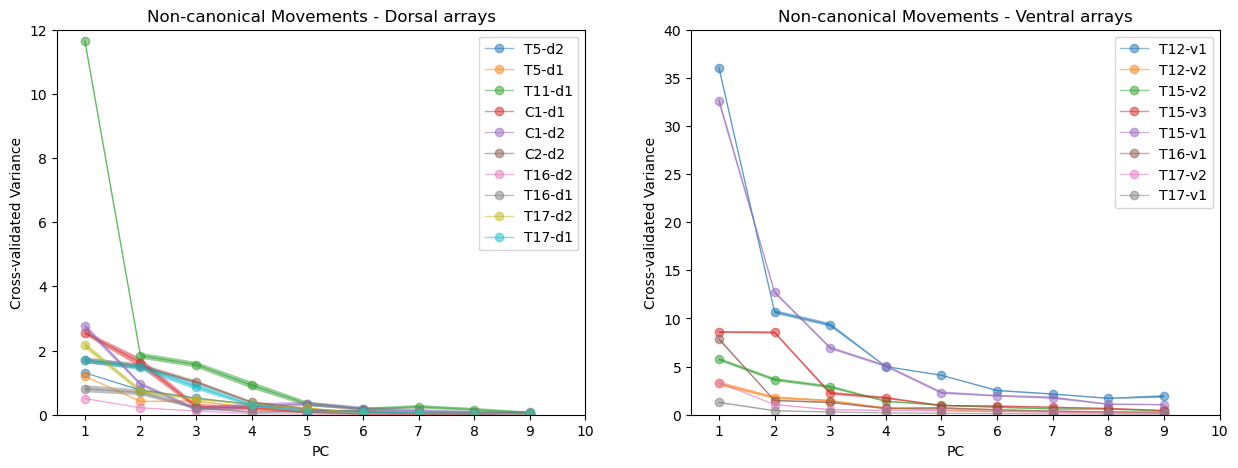

In [ ]:
# Plot cvPCA Results
numPCs = 9
# Set the following parameters to ensure text remains as text in the SVG
new_rc_params = {'text.usetex': False, "svg.fonttype": 'none'}
matplotlib.rcParams.update(new_rc_params)

dorsalArrays = {}
ventralArrays = {}
dorsalArrays_err = {}
ventralArrays_err = {}

for p in pNames:
    currDict = retDict[p]
    for chan in currDict.keys():
        if np.char.find(chan,'-d')>=0: # if a dorsal array
            dorsalArrays[chan] = currDict[chan][0][0]
            dorsalArrays_err[chan] = currDict[chan][3]
        elif np.char.find(chan,'-v')>=0:
            ventralArrays[chan] = currDict[chan][0][0]
            ventralArrays_err[chan] = currDict[chan][3]

# Generate figure
plt.figure(figsize=(15,5))

# Dorsal arrays subplot
plt.subplot(121)
for key,item in dorsalArrays.items():
    plt.plot(np.arange(1,numPCs+1), item[:numPCs], label=key, alpha=0.5, marker='o', linewidth=1)
    lower = np.array([i[0] for i in dorsalArrays_err[key]])
    higher = np.array([i[1] for i in dorsalArrays_err[key]])
    plt.fill_between(np.arange(1,numPCs+1), lower[:numPCs], higher[:numPCs], alpha=0.5)
    
plt.legend()
plt.xlim([0.5,10])
plt.ylim([0,12])
plt.xticks(range(1,11))
plt.title('Non-canonical Movements - Dorsal arrays')
plt.ylabel('Cross-validated Variance')
plt.xlabel('PC')

# Ventral arrays subplot
plt.subplot(122)
for key,item in ventralArrays.items():
    plt.plot(np.arange(1,numPCs+1), item[:numPCs], label=key, alpha=0.5, marker='o', linewidth=1)
    lower = np.array([i[0] for i in ventralArrays_err[key]])
    higher = np.array([i[1] for i in ventralArrays_err[key]])
    plt.fill_between(np.arange(1,numPCs+1), lower[:numPCs], higher[:numPCs], alpha=0.5)

plt.legend()
plt.xlim([0.5,10])
plt.xticks(range(1,11))
plt.ylim([0,40])
plt.title('Non-canonical Movements - Ventral arrays')
plt.ylabel('Cross-validated Variance')
plt.xlabel('PC')

# Create output directory and save figures
output_dir = Path('../../../../Data/ExtDataFigs/ExtDataFig3/')
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(output_dir / 'ExtDataFig3a_cvPCA.png')
plt.savefig(output_dir / 'ExtDataFig3a_cvPCA.svg')